# Aplicação Estatística a problemas reais da Biologia

Nesta aula vamos analisar o crescimento de **6 microrganismos** em cultura pura, extrair parâmetros biológicos das curvas de crescimento, e aplicar testes estatísticos para comparar os organismos entre si.

**Organismos em estudo:**

| Organismo | Tipo | Patogenicidade | Ambiente natural |
|---|---|---|---|
| *E. coli* K12 | Bactéria Gram− | Comensal | Intestino humano |
| *Salmonella enterica* | Bactéria Gram− | Patogénico | Intestino, alimentos |
| *L. acidophilus* | Bactéria Gram+ | Comensal/probiótico | Intestino, vagina |
| *C. difficile* | Bactéria Gram+ | Patogénico | Intestino (oportunista) |
| *S. cerevisiae* | Levedura | Comensal/probiótico | Intestino humano, alimentos, solo |
| *C. albicans* | Levedura | Patogénico (oportunista) | Intestino, vagina |

## Curvas de Crescimento

O crescimento microbiano segue um padrão **sigmoidal** bem caracterizado, com fases distintas: **lag**, **exponencial**, **estacionária** e **declínio**. A análise quantitativa destas curvas permite extrair parâmetros biológicos que descrevem o comportamento de cada cultura.

---

### Parâmetros-chave

| Parâmetro | Símbolo | Significado biológico | Unidade |
|---|---|---|---|
| Plateau | **A** | Densidade ótica máxima atingida (capacidade de carga) | OD600 |
| Taxa de crescimento máxima | **μ_max** | Inclinação máxima da curva — quão rápido as células se dividem | OD/h |
| Fase lag | **λ** | Tempo que a cultura demora a iniciar o crescimento exponencial | horas |

---

### Porquê estes parâmetros?

Estes três parâmetros permitem responder a questões práticas importantes, como:
- **Segurança alimentar:** Quanto tempo demora um patogénico a começar a multiplicar-se num alimento? (λ)
- **Produção industrial:** Qual o organismo que atinge maior biomassa? (A)
- **Competição entre espécies:** Quem cresce mais rápido e pode dominar uma co-cultura? (μ_max)


In [1]:
# Importar Pacotes

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# FASE 1 — Carregar e visualizar os dados

Antes de qualquer cálculo, é fundamental **olhar para os dados**. Vamos carregar o ficheiro CSV com as leituras de OD600 ao longo do tempo para as 6 estirpes (3 réplicas cada).

### 1.1 Abrir as medições de crescimento microbiano

O ficheiro `crescimento_microbiano.csv` contém leituras de **densidade ótica a 600 nm (OD600)** ao longo de 24 horas para as 6 estirpes, com 3 réplicas biológicas cada.

A OD600 é uma medida indireta da **concentração de células** em suspensão — quanto mais células, mais luz é dispersa e maior o valor de OD.

**Estrutura dos dados:**
- Cada **linha** = uma réplica de uma estirpe
- Cada **coluna** numérica = um ponto temporal (em horas)
- Colunas `Strain` e `Replicate` = identificação da amostra


In [2]:
# Carregar o CSV
df = pd.read_csv("crescimento_microbiano.csv")


In [3]:
print("Boas práticas: ")

print("Verifica as primeiras linhas do DataFrame:")
print(df.head(5))


Boas práticas: 
Verifica as primeiras linhas do DataFrame:
                Strain Replicate      0    0.5      1    1.5      2    2.5  \
0           E_coli_K12        R1  0.142  0.110  0.150  0.196  0.290  1.106   
1           E_coli_K12        R2  0.002  0.017  0.000  0.000  0.204  0.956   
2           E_coli_K12        R3  0.000  0.000  0.000  0.000  0.073  0.964   
3  Salmonella_enterica        R1  0.000  0.000  0.026  0.000  0.014  0.148   
4  Salmonella_enterica        R2  0.000  0.000  0.033  0.004  0.000  0.184   

       3    3.5  ...      5      6      7      8      9     10     12     16  \
0  2.092  2.571  ...  2.872  2.891  2.929  2.822  2.831  2.889  2.867  2.933   
1  1.928  2.399  ...  2.884  2.810  2.760  2.855  2.753  2.824  2.716  2.747   
2  1.824  2.239  ...  2.655  2.739  2.763  2.758  2.670  2.696  2.728  2.760   
3  0.727  1.537  ...  2.531  2.407  2.596  2.562  2.543  2.563  2.459  2.548   
4  0.793  1.596  ...  2.462  2.494  2.598  2.599  2.587  2.575  2.516  2

#### **Questão**

- Quantas medições temos no total? (linhas × colunas de tempo)
- Os valores de OD no tempo 0 são todos iguais? O que poderia explicar pequenas diferenças?

In [4]:
print("Verificar quais as condições a analisar:")
print(df['Strain'].unique())
print(df['Replicate'].unique())
print(df.columns.to_list()) 

Verificar quais as condições a analisar:
['E_coli_K12' 'Salmonella_enterica' 'L_acidophilus' 'C_difficile'
 'S_cerevisiae' 'C_albicans']
['R1' 'R2' 'R3']
['Strain', 'Replicate', '0', '0.5', '1', '1.5', '2', '2.5', '3', '3.5', '4', '4.5', '5', '6', '7', '8', '9', '10', '12', '16', '20', '24']


#### **Questão**
- No total quantas condições vamos analisar?

In [5]:
print("\nEstatísticas descritivas:")
print(df.describe())


Estatísticas descritivas:
               0        0.5          1        1.5          2        2.5  \
count  18.000000  18.000000  18.000000  18.000000  18.000000  18.000000   
mean    0.062778   0.068000   0.068222   0.075778   0.094833   0.240500   
std     0.082119   0.093634   0.096481   0.096642   0.095648   0.366672   
min     0.000000   0.000000   0.000000   0.000000   0.000000   0.000000   
25%     0.000000   0.000000   0.000000   0.000000   0.000000   0.002250   
50%     0.001000   0.020500   0.022500   0.022500   0.082000   0.094500   
75%     0.113000   0.101500   0.134500   0.153000   0.165750   0.234250   
max     0.232000   0.286000   0.351000   0.319000   0.290000   1.106000   

               3        3.5          4        4.5          5          6  \
count  18.000000  18.000000  18.000000  18.000000  18.000000  18.000000   
mean    0.511278   0.715778   0.858000   0.919222   0.951389   1.096889   
std     0.727000   0.976802   1.147606   1.211050   1.265501   1.176608 

#### **Questão**
- Como varia o desvio padrão com o tempo?

### Atribuição de estirpes por grupo

Cada grupo altera a variável `estirpe` na célula seguinte para o seu organismo:

| Grupo | Organismo | Tipo |
|---|---|---|
| 1 | `E_coli_K12` | Bactéria comensal |
| 2 | `Salmonella_enterica` | Bactéria patogénica |
| 3 | `L_acidophilus` | Bactéria probiótica |
| 4 | `C_difficile` | Bactéria patogénica |
| 5 | `S_cerevisiae` | Levedura comensal |
| 6 | `C_albicans` | Levedura patogénica |

**Pergunta:** Antes de correr o código, o que esperam? Um patogénico cresce mais rápido que um comensal? Uma levedura cresce mais devagar que uma bactéria?


### 1.2 Filtrar os dados da vossa estirpe

Filtramos a dataframe de maneira a selecionar apenas as linhas correspondentes à estirpe escolhida, e removemos as colunas não numéricas (Strain, Replicate).

In [6]:
estirpe = "E_coli_K12" # defina a estirpe a analisar

# Filtrar réplicas do microorganimo escolhido
df_estirpe = df[df["Strain"] == estirpe] # filtrar o dataframe para a estirpe escolhida
print(df_estirpe)

# Filtrar a dataframe para as colunas com dados apenas
columns = df.columns.to_list() # lista o nome das colunas do dataframe
print('Colunas')
print(columns)
time_cols = columns[2:]  # mantém apenas as colunas de tempo (assumindo que as 2 primeiras são 'Strain' e 'Replicate')
print('Colunas de tempo')
print(time_cols)
df_estirpe_time = df_estirpe[time_cols] # criar dataframe apenas com as colunas de tempo para a estirpe escolhida
print(f"DataFrame filtrado para a estirpe {estirpe}:\n{df_estirpe_time.head(5)}")

       Strain Replicate      0    0.5     1    1.5      2    2.5      3  \
0  E_coli_K12        R1  0.142  0.110  0.15  0.196  0.290  1.106  2.092   
1  E_coli_K12        R2  0.002  0.017  0.00  0.000  0.204  0.956  1.928   
2  E_coli_K12        R3  0.000  0.000  0.00  0.000  0.073  0.964  1.824   

     3.5  ...      5      6      7      8      9     10     12     16     20  \
0  2.571  ...  2.872  2.891  2.929  2.822  2.831  2.889  2.867  2.933  2.872   
1  2.399  ...  2.884  2.810  2.760  2.855  2.753  2.824  2.716  2.747  2.824   
2  2.239  ...  2.655  2.739  2.763  2.758  2.670  2.696  2.728  2.760  2.688   

      24  
0  2.847  
1  2.851  
2  2.702  

[3 rows x 22 columns]
Colunas
['Strain', 'Replicate', '0', '0.5', '1', '1.5', '2', '2.5', '3', '3.5', '4', '4.5', '5', '6', '7', '8', '9', '10', '12', '16', '20', '24']
Colunas de tempo
['0', '0.5', '1', '1.5', '2', '2.5', '3', '3.5', '4', '4.5', '5', '6', '7', '8', '9', '10', '12', '16', '20', '24']
DataFrame filtrado para a estir

### 1.3 Calcular média e desvio-padrão de todos os tempos

Para cada ponto temporal, calculamos a **média** e o **desvio-padrão** das 3 réplicas.

- A **média** dá-nos o valor central da medição
- O **desvio-padrão** indica a variabilidade entre réplicas — se é pequeno, as réplicas são consistentes


In [7]:
od_mean = df_estirpe_time.mean().values # calcular média para cada tempo
print(f"Médias calculadas por cada periodo de tempo analisado:\n{od_mean}")
od_std  = df_estirpe_time.std().values # calcular desvio-padrão para cada tempo
print(f"Desvios-padrão:\n{od_std}")
time_array = np.array(time_cols, dtype=float) # criar array de tempos a partir dos nomes das colunas
print(f"Array de tempos (horas): {time_array}")

Médias calculadas por cada periodo de tempo analisado:
[0.048      0.04233333 0.05       0.06533333 0.189      1.00866667
 1.948      2.403      2.65433333 2.74833333 2.80366667 2.81333333
 2.81733333 2.81166667 2.75133333 2.803      2.77033333 2.81333333
 2.79466667 2.8       ]
Desvios-padrão:
[0.08141253 0.0592143  0.08660254 0.11316065 0.10927488 0.08438799
 0.13511477 0.16603614 0.08324262 0.12761008 0.12888884 0.0760548
 0.0967178  0.04931869 0.08051294 0.09819878 0.08393053 0.10383801
 0.09544283 0.08489405]
Array de tempos (horas): [ 0.   0.5  1.   1.5  2.   2.5  3.   3.5  4.   4.5  5.   6.   7.   8.
  9.  10.  12.  16.  20.  24. ]


#### Questão

Olhando para a média dos valores, consegues antever:
- quando acaba a fase de adaptação do crescimento (lag)?
- quando começa  afase de crescimento exponencial?
- quando se inicia a fase estacinária?

### 1.4 Representação gráfica

Vamos representar a curva de crescimento com a média ± desvio-padrão (barras de erro), mas também todas as réplicas individualmente.


       Strain Replicate      0    0.5     1    1.5      2    2.5      3  \
0  E_coli_K12        R1  0.142  0.110  0.15  0.196  0.290  1.106  2.092   
1  E_coli_K12        R2  0.002  0.017  0.00  0.000  0.204  0.956  1.928   
2  E_coli_K12        R3  0.000  0.000  0.00  0.000  0.073  0.964  1.824   

     3.5  ...      5      6      7      8      9     10     12     16     20  \
0  2.571  ...  2.872  2.891  2.929  2.822  2.831  2.889  2.867  2.933  2.872   
1  2.399  ...  2.884  2.810  2.760  2.855  2.753  2.824  2.716  2.747  2.824   
2  2.239  ...  2.655  2.739  2.763  2.758  2.670  2.696  2.728  2.760  2.688   

      24  
0  2.847  
1  2.851  
2  2.702  

[3 rows x 22 columns]


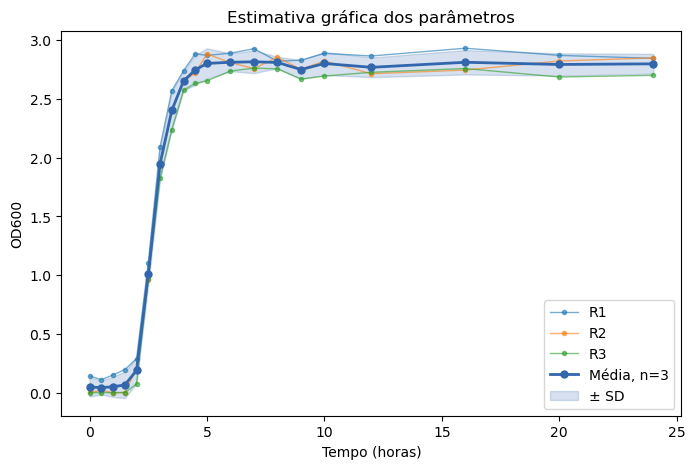

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))


print(df_estirpe)
# Réplicas individuais
for i, row in df_estirpe.iterrows():
    ax.plot(time_array, row[time_cols], #X = time, Y= valores de OD em cada tempo
            "o-", linewidth=1, markersize=3, alpha=0.6, label=row["Replicate"]) # label usando o nome da réplica

# Curva média
ax.plot(time_array, od_mean, #X = time, Y= média de OD em cada tempo
        "o-", color="#3266ad", linewidth=2, markersize=5, label='Média, n=3')

# Banda de desvio padrão
ax.fill_between(time_array, od_mean - od_std, od_mean + od_std, 
                # X = time, Y_baixo = valor mais baixo (média - std), Y_alto = valor mais alto (média + std)
                color="#3266ad", alpha=0.2, label="± SD")

ax.set_xlabel("Tempo (horas)")
ax.set_ylabel("OD600")
ax.set_title("Estimativa gráfica dos parâmetros")
ax.legend()

#mostra a imagem e fecha, permitindo a continua alteração da imagem
display(fig)
plt.close()

### **Questões**
- Conseguiram identificar as fases lag, exponencial e estacionária?
- Como se comparam as diferentes réplicas individualmente com a média e desvio padrão?

# FASE 2 — Calcular os parâmetros de crescimento

Agora vamos passar da observação ao cálculo. Para cada estirpe, vamos estimar os 3 parâmetros do modelo de Gompertz diretamente a partir dos dados:

| Passo | O que vamos fazer | Parâmetro | 
|-------|-------------------|-----------|
| 2.1 | Estimar o plateau (média dos últimos pontos) | **A** |
| 2.2 | Calcular a taxa máxima de crescimento (ΔOD/Δt) | **μ_max** |
| 2.3 | Estimar a fase lag a partir do ponto de inflexão | **λ** |

Cada grupo vai analisar **um microrganismo** e no final juntamos os resultados de todos.

### 2.1 Crescimento máximo — Plateau ou Fase Estacionária (A)

O plateau (A) representa a **densidade ótica máxima** que a cultura atinge — o ponto em que o crescimento estabiliza porque os nutrientes se esgotam ou os produtos tóxicos se acumulam.

Estimamos A como a **média dos últimos pontos temporais**, onde a curva já estabilizou.

**O que determina o valor de A?**
- **Capacidade de carga do meio:** quantidade de nutrientes disponíveis
- **Tolerância a produtos metabólicos:** ácidos, etanol, toxinas que se acumulam
- **Tamanho celular:** a mesma OD600 pode corresponder a números diferentes de células conforme o organismo (bactérias são mais pequenas que leveduras)

**Questão:** 
- Se duas estirpes crescem no mesmo meio, mas uma atinge um plateau mais alto, o que pode explicar a diferença?


Estimativas gráficas para E_coli_K12:
  Plateau (A) média ≈ 2.797222222222222
  R1: Plateau ≈ 2.8756666666666666
  R2: Plateau ≈ 2.7933333333333334
  R3: Plateau ≈ 2.7226666666666666


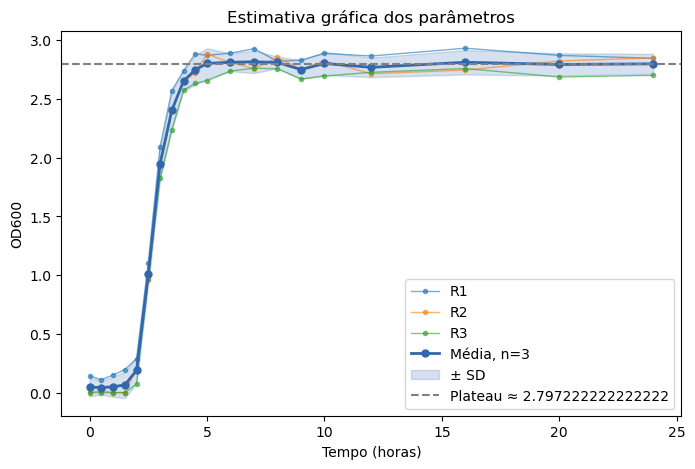

In [9]:
# ── Plateau (A) ─────────────────────────────────────────
#Calcular o plateu médio
valores_A = od_mean[11:] # selecionar os valores a partir do tempo onde a curva parece estabilizar (usar o array de médias)
A_estimado = valores_A.mean() # calcular a média dos valores para obter a estimativa do plateau
print(f"\nEstimativas gráficas para {estirpe}:")
print(f"  Plateau (A) média ≈ {A_estimado}")

# calcular o plateau para cada réplica individualmente
for i, row in df_estirpe_time.iterrows(): #cria um loop for
    od_rep = row.values.astype(float) # extrair os valores de OD da réplica
    od_A_rep = od_rep[11:] # selecionar os valores di 
    A_rep  = od_A_rep.mean() # calcular o plateau da réplica
    print(f"  {df_estirpe.loc[i, 'Replicate']}: Plateau ≈ {A_rep}")

#visualiza o valor médio do plateau no gráfico
ax.axhline(A_estimado, color="gray", linestyle="--", label=f"Plateau ≈ {A_estimado}") 
ax.legend()

display(fig)
plt.close()

### 2.2 Taxa de crescimento máxima (μ_max)

A taxa de crescimento máxima corresponde à **inclinação máxima** da curva — o momento em que as células se estão a dividir mais rapidamente (fase exponencial).

Calculamos μ_max como a derivada numérica da curva:

$$\mu_{max} = \max\left(\frac{\Delta OD}{\Delta t}\right)$$

Ou seja, para cada par de pontos consecutivos calculamos a variação de OD por hora (ΔOD/Δt) e ficamos com o **valor máximo**.

**O que influencia μ_max?**
- **Tipo de divisão celular:** bactérias (fissão binária, ~20 min) vs leveduras (gemulação, ~90 min)
- **Meio de cultura:** disponibilidade de nutrientes, temperatura, pH
- **Metabolismo:** aeróbio vs anaeróbio, fermentativo vs respiratório


Valores de OD para crescimento exponencial: [1.948      2.403      2.65433333]
Tempos correspondentes: [3.  3.5 4. ]
Taxa de crescimento (ΔOD): [0.455      0.25133333]
Intervalos de tempo (Δt): [0.5 0.5]
Taxa de crescimento por hora (ΔOD/Δt): [0.91       0.50266667]
  R1: μ_max ≈ 0.9580000000000002 OD/h
  R2: μ_max ≈ 0.9420000000000002 OD/h
  R3: μ_max ≈ 0.8299999999999996 OD/h
O crescimento máximo de 0.9100000000000006 OD/h ocorre no tempo de 3.0 horas
Estimativas gráficas para E_coli_K12:
  Plateau (A)  ≈ 2.797
  μ_max        ≈ 0.910 OD/h


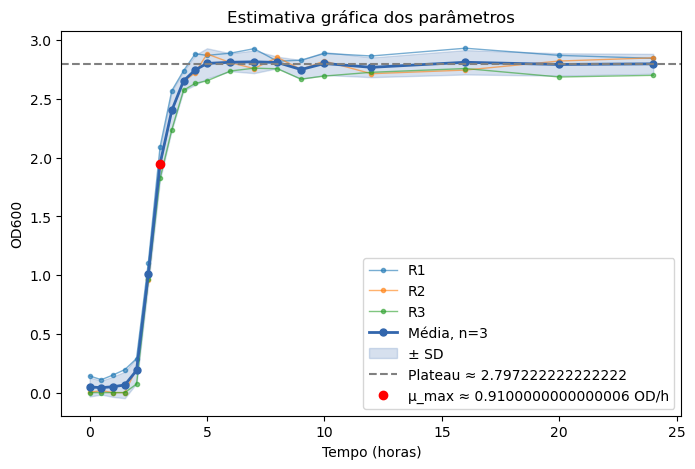

In [10]:
# ── Taxa máxima (mu) ────────────────────────────────────
values_umax = od_mean[6:9] # selecionar os valores de OD para os tempos de crescimento exponencial
print(f"Valores de OD para crescimento exponencial: {values_umax}")

time_umax = time_array[6:9] # selecionar os tempos correspondentes aos valores de OD
print(f"Tempos correspondentes: {time_umax}")

dod = np.diff(values_umax) # calcular a diferença entre os valores de OD para obter a taxa de crescimento
print(f"Taxa de crescimento (ΔOD): {dod}")

dt = np.diff(time_umax) # calcular intervalo de tempo
print(f"Intervalos de tempo (Δt): {dt}")

dod_dt = dod / dt # aplicar a fórmula da taxa de crescimento (ΔOD/Δt)
print(f"Taxa de crescimento por hora (ΔOD/Δt): {dod_dt}")

# calcular mu para cada réplica individualmente
for i, row in df_estirpe_time.iterrows():
    od_rep      = row.values.astype(float) # extrair os valores de OD da réplica
    dod_dt_rep  = np.diff(od_rep[6:9]) / np.diff(time_umax) # calcular a taxa de crescimento da réplica
    mu_rep      = np.max(dod_dt_rep) # estimar μ_max da réplica
    print(f"  {df_estirpe.loc[i, 'Replicate']}: μ_max ≈ {mu_rep} OD/h")

mu_estimado  = np.max(dod_dt) # encontrar the maximum value of the growth rate to estimate μ_max
idx_max = np.argmax(dod_dt) # encontrar o índice no array no valor máximo
time_mu_max  = time_umax[idx_max] # para identificar o tempo correspondente
print(f"O crescimento máximo de {mu_estimado} OD/h ocorre no tempo de {time_mu_max} horas")


ax.plot(time_umax[idx_max], values_umax[idx_max], "o", color="red", 
        label=f"μ_max ≈ {mu_estimado} OD/h")
ax.legend()

print(f"Estimativas gráficas para {estirpe}:")
print(f"  Plateau (A)  ≈ {A_estimado:.3f}")
print(f"  μ_max        ≈ {mu_estimado:.3f} OD/h")

display(fig)
plt.close()

### 2.3 Estimativa da Fase Lag (λ)

A fase lag é calculada a partir do ponto de inflexão da curva:

$$\lambda = t_{inf} - \frac{OD_{inf} - OD_0}{\mu_{max}}$$

Onde:
- **t_inf** — tempo no ponto de inflexão (onde o crescimento é mais rápido)
- **OD_inf** — valor de OD nesse ponto
- **OD_0** — valor de OD no tempo zero
- **μ_max** — taxa de crescimento máxima (calculada no passo anterior)


#### **Questão:** 
- Um organismo com uma fase lag longa é vantajoso ou desvantajoso? Depende do contexto?
-- Num probiótico, uma lag curta pode ser benéfica (coloniza rapidamente)
-- Num patogénico alimentar, a lag dá-nos uma "janela de segurança" antes da contaminação

Limite de crescimento em fase Lag: 0.148
Valores acima do threshold: [False False False False  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True]
[False False False False  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True]
Tempos acima do crescimento lag: {higher_threshold_values}
Tempo que o crescimento sai de fase lag: {lam_estimado}
  R1: Lag ≈ 2.000 h
  R2: Lag ≈ 2.000 h
  R3: Lag ≈ 2.500 h
Estimativas gráficas para E_coli_K12:
  Plateau (A)  ≈ 2.797222222222222
  μ_max        ≈ 0.9100000000000006 OD/h
  Fase lag     ≈ 2.0 h


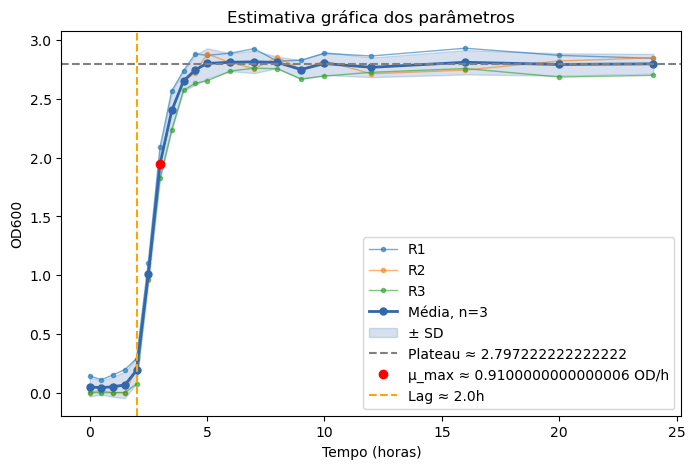

In [11]:
threshold = od_mean[0] + 0.1 # OD inicial + margem para ignorar ruído
print(f'Limite de crescimento em fase Lag: {threshold}')

values_above_threshold = od_mean > threshold # cria um array booleano - True/False
print(f'Valores acima do threshold: {values_above_threshold}')
print(values_above_threshold)

higher_threshold_values = time_array[values_above_threshold] 
print('Tempos acima do crescimento lag: {higher_threshold_values}')

lam_estimado = higher_threshold_values[0] # primeiro tempo onde OD ultrapassa o threshold
print('Tempo que o crescimento sai de fase lag: {lam_estimado}')

# calcular lam para cada réplica individualmente
for i, row in df_estirpe_time.iterrows():
    od_rep  = row.values # extrair os valores de OD da réplica
    lam_rep = time_array[od_rep > od_rep[0] + 0.1][0] # primeiro tempo onde OD ultrapassa o threshold
    print(f"  {df_estirpe.loc[i, 'Replicate']}: Lag ≈ {lam_rep:.3f} h")

ax.axvline(lam_estimado, color="orange", linestyle="--", label=f"Lag ≈ {lam_estimado}h") # representar graficamente
ax.legend()

print(f"Estimativas gráficas para {estirpe}:")
print(f"  Plateau (A)  ≈ {A_estimado}")
print(f"  μ_max        ≈ {mu_estimado} OD/h")
print(f"  Fase lag     ≈ {lam_estimado} h")

display(fig)
plt.close()

# FASE 3 — Comparar o crescimento das diferentes estirpes

### 3.1 Tabela resumo dos parâmetros de crescimento

Depois de estimados os parâmetros para todas as estirpes, compilamos os resultados numa tabela com a **média ± desvio-padrão** (3 réplicas) de cada parâmetro:

| Parâmetro | O que representa | Como foi estimado |
|---|---|---|
| **A** (mean ± sd) | Plateau — densidade máxima atingida | Média dos últimos 5 pontos temporais |
| **μ_max** (mean ± sd) | Taxa de crescimento máxima | Máximo de ΔOD/Δt na fase exponencial |
| **λ** (mean ± sd) | Fase lag — tempo até iniciar crescimento | Fórmula: λ = t_inf − (OD_inf − OD₀) / μ_max |

A tabela resultante terá este formato — **uma linha por estirpe, com média e desvio-padrão de cada parâmetro**:

| Strain | Replicate | A_mean | A_sd | mu_mean | mu_sd | lam_mean | lam_sd |
|---|---|---|---|---|---|---|---|
| C_albicans | ... | ... | ... | ... | ... | ... | ... |
| C_difficile | ... | ... | ... | ... | ... | ... | ... |
| E_coli_K12 | ... | ... | ... | ... | ... | ... | ... |
| L_acidophilus | ... | ... | ... | ... | ... | ... | ... |
| S_cerevisiae | ... | ... | ... | ... | ... | ... | ... |
| Salmonella_enterica | ... | ... | ... | ... | ... | ... | ... |

**Perguntas ao olhar para a tabela:**
- Qual a estirpe com maior variabilidade (SD alto) em cada parâmetro? O que pode explicar isso?


In [ ]:

resultados = pd.DataFrame(columns=["Strain", "Replicate"] + list(time_array)) #cria as colunas necessárias na dataframe
print('Empty DataFrame:')
print(resultados)


def calcular_parametros(t, od): # cria função para calcular os parÂmetros de crescimento
    
    # Plateau — média dos últimos 20% dos pontos
    n_plateau = max(3, int(0.2 * len(od)))
    A = od[-n_plateau:].mean()

    # Derivada numérica (diferenças finitas)
    dod_dt = np.diff(od) / np.diff(t)
    t_mid  = (t[:-1] + t[1:]) / 2

    # mu_max — valor máximo da derivada
    idx_max = np.argmax(dod_dt)
    mu      = dod_dt[idx_max]

    # Fase lag — threshold
    threshold = od[0] + 0.1
    lam = t[od > threshold][0]

    return A, mu, lam


for estirpe in df["Strain"].unique(): # iterar por estirpe
    df_estirpe = df[df["Strain"] == estirpe] # filtrar por estirpe
    df_estirpe_time = df_estirpe[time_cols] # manter apenas colunas com valores de crescimento

    for i, row in df_estirpe_time.iterrows(): # iterar df_estirpe_time 
        od_rep = row.values # valores de OD da linha 
        A, mu, lam = calcular_parametros(time_array, od_rep)
        resultados.loc[i, "Strain"]    = estirpe
        resultados.loc[i, "Replicate"] = df_estirpe.loc[i, "Replicate"]

df_params = pd.DataFrame(resultados).set_index(["Strain", "Replicate"])

df_resumo = df_params.groupby("Strain").agg(
    A_mean=("A", "mean"), A_sd=("A", "std"),
    mu_mean=("mu", "mean"), mu_sd=("mu", "std"),
    lam_mean=("lam", "mean"), lam_sd=("lam", "std")
).round(3)

print("Parâmetros por réplica:")
print(df_params.to_string())
print("\nResumo (média ± SD por estirpe):")
print(df_resumo.to_string())

Empty DataFrame:
Empty DataFrame
Columns: [Strain, Replicate, 0.0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 12.0, 16.0, 20.0, 24.0]
Index: []

[0 rows x 22 columns]


KeyError: "Column(s) ['A', 'lam', 'mu'] do not exist"

### 3.1 Simulação das curvas de crescimento — Modelo de Gompertz

Tendo os 3 parâmetros estimados (A, μ_max, λ) para cada estirpe, podemos reconstruir a curva de crescimento completa usando o **modelo de Gompertz modificado**:

$$OD(t) = A \cdot \exp\left(-\exp\left(\frac{\mu_{max} \cdot e}{A} \cdot (\lambda - t) + 1\right)\right)$$

Isto permite-nos **sobrepor todas as estirpes no mesmo gráfico** e comparar visualmente:
- Quem arranca primeiro? (λ mais curto = curva desloca-se para a esquerda)
- Quem cresce mais rápido? (μ_max maior = curva mais íngreme)
- Quem atinge maior densidade? (A maior = plateau mais alto)

**Pergunta:** Olhando para o gráfico, consigam identificar os dois grandes grupos (bactérias vs leveduras). O que os distingue?

In [ ]:
fig_all, ax_all = plt.subplots(figsize=(10, 6))

def gompertz(t, A, mu, lam):
    return A * np.exp(-np.exp((mu * np.e / A) * (lam - t) + 1))


t_curva = np.linspace(0, time_array[-1], 200)

for estirpe, cor in zip(df["Strain"].unique()):
    params   = df_resumo.loc[estirpe]
    od_curva = gompertz(t_curva, params["A_mean"], params["mu_mean"], params["lam_mean"])
    ax_all.plot(t_curva, od_curva, color=cor, linewidth=2, label=estirpe.replace("_", " "))

ax_all.set_xlabel("Tempo (horas)")
ax_all.set_ylabel("OD600")
ax_all.legend()
ax_all.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 3.2 Visualização comparativa de parâmetros de crescimento

- Comparem A com μ_max: os organismos que crescem mais rápido são os que atingem maior densidade?

In [ ]:
fig_bar, ax_bar = plt.subplots(1, 3, figsize=(14, 5))

params_plot = [
    ("A_mean",   "A_sd",   "Plateau (A)",    "OD600"),
    ("mu_mean",  "mu_sd",  "Taxa máxima (µ)", "OD/h"),
    ("lam_mean", "lam_sd", "Fase lag (λ)",    "horas"),
]


estirpes = df_resumo.index.tolist()

for ax, (mean_col, sd_col, titulo, unidade) in zip(ax_bar, params_plot):
    valores = df_resumo[mean_col].values
    erros   = df_resumo[sd_col].values

    bars = ax.bar(range(len(estirpes)), valores, yerr=erros, capsize=5, edgecolor="white", linewidth=0.5)

    ax.set_xticks(range(len(estirpes)))
    ax.set_xticklabels([e.replace("_", "\n") for e in estirpes], fontsize=8)
    ax.set_title(titulo)
    ax.set_ylabel(unidade)
    ax.grid(axis="y", alpha=0.3)

plt.suptitle("Comparação de parâmetros de crescimento (média ± SD)", fontsize=13)
plt.tight_layout()
plt.show()

### 3.3 Os parâmetros de crescimento são estatisticamente diferentes entre estirpes?

Visualmente, as curvas e gráficos de barras parecem diferentes — mas será que essas diferenças são **estatisticamente significativas** ou podem ser apenas variabilidade experimental?

Para responder, vamos aplicar:

1. **ANOVA One-way** — testa se existe pelo menos uma estirpe diferente das outras (para cada parâmetro)
2. **Tukey HSD** (post-hoc) — se a ANOVA for significativa, identifica **quais pares** de estirpes são diferentes

Relembrando:
- **p < 0.05** → diferença significativa (rejeitamos H₀)
- **p ≥ 0.05** → sem evidência de diferença (não rejeitamos H₀)

**Perguntas ao analisar os resultados:**
- Para qual dos 3 parâmetros (A, μ, λ) existem mais diferenças significativas entre estirpes?
- Há estirpes que não são significativamente diferentes entre si? Quais? Faz sentido biologicamente?
- *E. coli* e *Salmonella* (ambas Enterobacteriaceae) têm parâmetros semelhantes? E *S. cerevisiae* e *C. albicans* (ambas leveduras)?

In [ ]:
from scipy import stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# ── Definir grupos ───────────────────────────────────────
bacterias = ["E_coli_K12", "Salmonella_enterica", "L_acidophilus", "C_difficile"]
leveduras = ["S_cerevisiae", "C_albicans"]

# ══════════════════════════════════════════════════════════
# ANÁLISE PAIRWISE — todas as estirpes entre si
# ══════════════════════════════════════════════════════════
for param, titulo in [("A", "Plateau (A)"), ("mu", "Taxa máxima (µ)"), ("lam", "Fase lag (λ)")]:
    print(f"\n{'═'*55}")
    print(f"{titulo}")
    print(f"{'═'*55}")

    grupos = {e: df_params.loc[e][param].values for e in df_params.index.get_level_values("Strain").unique()}

    # ── ANOVA entre todas as estirpes ────────────────────
    f_stat, p_anova = stats.f_oneway(*grupos.values())
    print(f"\nANOVA (todas as estirpes): F={f_stat:.3f}, p={p_anova:.4f}")

    # ── Tukey HSD post-hoc ───────────────────────────────
    valores = np.concatenate(list(grupos.values()))
    labels  = np.concatenate([[e]*3 for e in grupos.keys()])
    tukey   = pairwise_tukeyhsd(valores, labels, alpha=0.05)
    print("\nTukey HSD:")
    print(tukey.summary())

### 3.4 Os parâmetros de crescimento são estatisticamente diferentes entre Bactérias e Leveduras

Agora agrupamos os organismos por **tipo** (bactérias vs leveduras) e testamos se há diferenças entre os dois grupos.

**Perguntas:**
- As bactérias atingem um plateau mais alto que as leveduras? É significativo?
- As leveduras demoram mais a iniciar o crescimento? O que pode explicar isso biologicamente?
- A taxa de crescimento é diferente? As bactérias dividem-se por **fissão binária** (rápido) e leveduras por **gemulação** (mais lento)


In [ ]:
# ══════════════════════════════════════════════════════════
# ANÁLISE POR GRUPO — bactérias vs leveduras
# ══════════════════════════════════════════════════════════
for param, titulo in [("A", "Plateau (A)"), ("mu", "Taxa máxima (µ)"), ("lam", "Fase lag (λ)")]:
    print(f"\n{'═'*55}")
    print(f"{titulo}")
    print(f"{'═'*55}")

    grupos = {e: df_params.loc[e][param].values for e in df_params.index.get_level_values("Strain").unique()}

    # ── Bactérias vs Leveduras ───────────────────────────
    vals_bact = np.concatenate([grupos[e] for e in bacterias])
    vals_lev  = np.concatenate([grupos[e] for e in leveduras])
    t_stat, p_ttest = stats.ttest_ind(vals_bact, vals_lev)
    print(f"\nt-test bactérias vs leveduras: t={t_stat:.3f}, p={p_ttest:.4f}")
    print(f"  bactérias: média={vals_bact.mean():.3f} ± {vals_bact.std():.3f}")
    print(f"  leveduras: média={vals_lev.mean():.3f} ± {vals_lev.std():.3f}")

### 3.4 Os parâmetros de crescimento são estatisticamente diferentes entre Patogénicas vs Comensais

Será que os organismos **patogénicos** crescem de forma diferente dos **comensais**? Separamos a análise para bactérias e leveduras.

| Bactérias patogénicas | Bactérias comensais | Leveduras patogénicas | Leveduras comensais |
|---|---|---|---|
| *Salmonella*, *C. difficile* | *E. coli* K12, *L. acidophilus* | *C. albicans* | *S. cerevisiae* |

**Perguntas para discussão:**
- Há diferenças significativas entre patogénicos e comensais dentro das bactérias? E dentro das leveduras?
- Se *C. albicans* (patogénica) cresce mais devagar que *S. cerevisiae* (comensal), isso pode ser uma desvantagem competitiva numa co-cultura?


In [ ]:
# ── Bactérias patogénicas vs comensais ──────────────────
bact_patogenicas = ["Salmonella_enterica", "C_difficile"]
bact_comensais   = ["E_coli_K12", "L_acidophilus"]

# ── Leveduras patogénicas vs comensais ──────────────────
lev_patogenicas = ["C_albicans"]
lev_comensais   = ["S_cerevisiae"]

for param, titulo in [("A", "Plateau (A)"), ("mu", "Taxa máxima (µ)"), ("lam", "Fase lag (λ)")]:
    print(f"\n{'═'*55}")
    print(f"{titulo}")
    print(f"{'═'*55}")

    grupos = {e: df_params.loc[e][param].values for e in df_params.index.get_level_values("Strain").unique()}

    # ── Bactérias patogénicas vs comensais ───────────────
    vals_bact_pat = np.concatenate([grupos[e] for e in bact_patogenicas])
    vals_bact_com = np.concatenate([grupos[e] for e in bact_comensais])
    t_stat, p_ttest = stats.ttest_ind(vals_bact_pat, vals_bact_com)
    print(f"\nt-test bactérias patogénicas vs comensais: t={t_stat:.3f}, p={p_ttest:.4f}")
    print(f"  patogénicas: média={vals_bact_pat.mean():.3f} ± {vals_bact_pat.std():.3f}")
    print(f"  comensais:   média={vals_bact_com.mean():.3f} ± {vals_bact_com.std():.3f}")

    # ── Leveduras patogénicas vs comensais ───────────────
    vals_lev_pat = np.concatenate([grupos[e] for e in lev_patogenicas])
    vals_lev_com = np.concatenate([grupos[e] for e in lev_comensais])
    t_stat, p_ttest = stats.ttest_ind(vals_lev_pat, vals_lev_com)
    print(f"\nt-test leveduras patogénicas vs comensais: t={t_stat:.3f}, p={p_ttest:.4f}")
    print(f"  patogénicas: média={vals_lev_pat.mean():.3f} ± {vals_lev_pat.std():.3f}")
    print(f"  comensais:   média={vals_lev_com.mean():.3f} ± {vals_lev_com.std():.3f}")

# FASE 4 — Conclusões

Respondam em grupo às seguintes questões:

1. **Ranking de crescimento:** Ordenem os 6 organismos do mais rápido ao mais lento. Coincidem com o que esperavam?

2. **Bactérias vs leveduras:** Quais as principais diferenças? São estatisticamente significativas para todos os parâmetros?

3. **Patogénicos vs comensais:** A patogenicidade está associada a um padrão de crescimento diferente?

4. **Previsão para co-cultura:** Com base nestes resultados, o que esperam que aconteça quando os 6 organismos crescerem juntos?
   - Quem vai dominar?
   - Quem pode ser eliminado?
   - Que mecanismos de interação podem ocorrer? (competição, produção de bacteriocinas, alteração de pH...)

---

**Na próxima aula:** Vamos usar **RT-PCR** com primers específicos para verificar a presença de cada espécie numa co-cultura real — e ver se as vossas previsões estavam corretas!
